# Antenna-position error vs the foreground subspace

The paper trail for the two horizon figures, end to end: raw simulation
output in, `horizon_perturbations_1col.pdf` and `horizon_shift.pdf` out.
Everything in between -- the antenna-temperature differences, the foreground
eigenbasis, the 21 cm benchmark, the operating point, and every number quoted
in the text -- is derived here rather than imported from a script.

**The question.** The EIGSEP antenna hangs from a suspension system, so its
position is known only to some tolerance. A position error moves the horizon,
which changes the beam-weighted foreground, which changes
$T_\mathrm{ant}(\nu)$. How large is that change, how *foreground-like* is it,
and how well must the position be known?

**The method.** Take the difference between the antenna temperature at a
displaced position and at the nominal one, project it onto the spectral
eigenmodes of the *unperturbed* antenna temperature, and ask how much survives
filtering the leading $N$ of them -- measured against the 21 cm signal retained
under the identical projection.

**What this is not.** Neither figure is a proposed analysis. Both project onto
eigenmodes of a *simulated* nominal instrument. An unmodelled displacement of
the size we have to anticipate deposits signal-like power in the first mode
past the filter, so a residual left by a filter of fixed depth is not evidence
of a cosmological signal. These characterise spectral structure; the analysis
marginalises over antenna position inside a forward model instead, and the
sensitivities here are what set its priors.

**Inputs** (both gitignored -- regenerate with the commands in `../README.md`):

| file | from |
|---|---|
| `../output/horizons_position.npz` | `make_horizons.py` (eigsep_terrain env) |
| `../output/position_sims.npz` | `run_sims.py` |
| `../../models_21cm/output/zeus21_models.npz` | `models_21cm/generate.py` |

**Run order.** `signal_loss.ipynb` (Fig. 1) reads the `Vh` this notebook
writes into `horizon_shift.npz`, so run this notebook first, then that one.

In [1]:
import sys
from pathlib import Path

import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time
from astropy.utils import iers
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

iers.conf.auto_download = False   # offline; the LST conversion needs no fresh IERS
iers.conf.auto_max_age = None

HERE = Path.cwd()                 # horizon_position/notebooks
sys.path.insert(0, str(HERE.parent))          # paper.py, analysis.py
import analysis
import paper
sys.path.insert(0, str(paper.ROOT / "models_21cm"))
import selection

# Where the paper's committed npz + notebook + PDF live (npz archived to Zenodo).
PAPER = paper.PAPER
# Figures rendered below are previews for reading this notebook. Under the
# figure-workflow spec (2026-09-09) eigsep_paper_notebooks owns the paper
# figures -- it builds them through eigsep_style, which is what holds them to
# the manuscript's geometry contract. This repo supplies the data.
PREVIEW = paper.SIMS_NPZ.parent / "preview"
PREVIEW.mkdir(parents=True, exist_ok=True)

N_SHOW = paper.N_SHOW             # foreground modes on the residual-panel x-axis
MAGS_M = (0.1, 1.0, 10.0)         # the positive displacements run_sims.py simulated
TOP_MAG = 1.0                     # the one the spectra row draws; must be in MAGS_M
AXES_ENU = [("x", "East"), ("y", "North"), ("z", "Up")]
n_modes = np.arange(N_SHOW + 1)
assert TOP_MAG in MAGS_M

## 1. Inputs

### 1.1 The simulated antenna temperature

`run_sims.py` ran `eigsim.simulate` at zenith pointing for 19 antenna positions
-- nominal, plus $\pm$0.1, $\pm$1, $\pm$10 m along each of East / North / Up --
each with its own continuous horizon from the Marjum DEM turned into an
anti-aliased open-sky mask. Index 0 is nominal.

`t_sys` is the system temperature: sky + ground pickup + a constant 50 K
receiver. `fgnd` is the fractional ground pickup per channel.

In [2]:
d = np.load(paper.SIMS_NPZ, allow_pickle=True)
t_sys, fgnd = d["t_sys"], d["fgnd"]          # (19, n_time, n_f) K, (19, n_f)
names = [str(n) for n in d["names"]]
freqs = d["freqs_mhz"]                       # (n_f,) MHz
t_gnd, t_rcvr = float(d["t_ground"]), float(d["t_receiver"])
n_time, n_f = t_sys.shape[1], freqs.size

print(f"{len(names)} positions, {n_time} times, {n_f} channels "
      f"({freqs[0]:.0f}-{freqs[-1]:.0f} MHz)")
print(f"T_ground = {t_gnd:g} K, T_receiver = {t_rcvr:g} K, "
      f"nominal ground pickup = {fgnd[0].mean():.4f}")
print("positions:", ", ".join(names))

19 positions, 1436 times, 201 channels (50-250 MHz)
T_ground = 300 K, T_receiver = 50 K, nominal ground pickup = 0.5537
positions: nominal, x_m_0p1, x_p_0p1, x_m_1, x_p_1, x_m_10, x_p_10, y_m_0p1, y_p_0p1, y_m_1, y_p_1, y_m_10, y_p_10, z_m_0p1, z_p_0p1, z_m_1, z_p_1, z_m_10, z_p_10


### 1.2 The 21 cm model ensemble

4096 global-signal models from Zeus21 (Muñoz 2023a, arXiv:2302.08506) with
Pop III star formation and Lyman-Werner feedback (Cruz et al. 2024,
arXiv:2407.18294), Sobol-sampled over 14 astrophysical parameters and already
spline-interpolated onto the paper frequency grid. The npz carries its own
regeneration recipe in its `provenance`, `generator_source` and `env_lock` keys.

**The ensemble is attenuated by the open-sky fraction**, exactly as in
`signal_loss.ipynb`. Everything on the residual panels is uncorrected antenna
temperature -- `t_sys` differences, filtered in a basis built from `t_sys` --
and an isotropic global signal reaches that observable as
$\eta(\nu)\,T_{21}(\nu)$ with $\eta = 1 - f_\mathrm{gnd}$. Without the
factor this figure would compare an antenna-temperature systematic against a
sky-referred signal and understate the systematic by 2.2$\times$.

$\eta$ is taken from the *nominal* position for every curve. Each displaced
position has its own, but a 1 m vertical shift changes it by 0.15 per cent
(10 m by 1.4 per cent, 1 m horizontally by less than 0.04), which is invisible
on a log axis spanning decades and would fork the grey band into 19
indistinguishable copies. The same $\Delta\eta$ that would brighten the
signal by 1.7 $\mu$K is what makes the systematic in the first place, because
there it multiplies $T_\mathrm{sky} - T_\mathrm{gnd}$ rather than $T_{21}$ --
see section 3.

A **posterior reionization cut** is applied here, once, so the figure and the
quoted statistics can never disagree about which models are in.
`reionized_across_band` (not plain `reionized`) is deliberate: it requires the
model to be reionized across the whole band, excluding 43 models whose Zeus21
Q-solution re-neutralises at low $z$ -- 27 of those carry more than 1 mK of
unphysical signal at 250 MHz. The $z = 5.9$ threshold is inherited from
McGreer et al. 2015, since superseded by Davies et al. 2025 (MNRAS 545,
arXiv:2510.25829). It is kept because it is not load-bearing, not because it
is conservative: `../reionization_sensitivity.py` shows that every variant the
current data admit -- the Davies ladder included -- leaves the reported
numbers where they are.

The assert is the guard that keeps this figure and Fig. 1 cutting the same
models.

In [3]:
m = np.load(paper.MODELS_NPZ, allow_pickle=False)
assert np.array_equal(m["freqs_MHz"], freqs), "21 cm grid != simulation grid"

keep = selection.reionized_across_band(m["xHI"], m["z_xHI"])
# eta: the beam-weighted open-sky fraction at the nominal position. Derived
# here from this notebook's own fgnd, not imported -- signal_loss.ipynb does
# the same from foreground_svd.npz, and paper.N_ANCHOR is the assert that
# catches the two disagreeing.
eta = 1.0 - fgnd[0]                          # (n_f,)
T21 = eta * m["T21_mK"][keep] * 1e-3         # (n_model, n_f) K, as observed
# signal_loss.ipynb applies the identical cut and asserts the same count, so
# the two figures cannot quote percentiles off different ensembles.
assert keep.sum() == paper.N_MODELS, (
    f"{keep.sum()} models survive the cut, expected {paper.N_MODELS} -- "
    "the ensemble moved; update paper.N_MODELS and re-run both notebooks"
)
print(f"{keep.sum()} of {keep.size} models survive the reionization cut")

1769 of 4096 models survive the reionization cut


## 2. The geometric perturbation

Before any radiometry: what does moving the antenna do to the horizon? The
continuous elevation profile $\alpha_h(\mathrm{az})$ comes from
`eigsep_terrain.calc_horizon` on the Marjum DEM, one profile per position
(azimuth $= \mathrm{atan2}(E, N)$, North$\to$East).

A 1 m move changes the horizon by $\lesssim 0.1^\circ$ over most azimuths and
spikes to $\sim 1^\circ$ only at steep cliff edges, where a lateral move slides
a near-vertical horizon edge sideways. Raising the antenna lowers the horizon by
a near-uniform small offset -- which is why, further down, the *vertical*
response is the one that scales linearly with displacement.

This is **Fig. `horizon_perturbations_1col.pdf`** in the paper.

In [4]:
h = np.load(paper.HORIZONS_NPZ, allow_pickle=True)
h_names = [str(n) for n in h["names"]]
az = np.degrees(h["az_grid"])                # (n_az,) deg
alpha = np.degrees(h["alpha_h"])             # (19, n_az) deg
assert h_names == names, "horizon file and simulation file disagree on positions"
assert str(h["pos_sha"]) == str(d["pos_sha"]), "position_sims.npz is stale"

base = alpha[h_names.index("nominal")]
print(f"nominal horizon: median {np.median(base):.2f} deg, max {base.max():.2f} deg")
for tag, lab in AXES_ENU:
    dh = alpha[h_names.index(f"{tag}_p_1")] - base
    print(f"  {lab:5s} +1 m: median |d_alpha| {np.median(np.abs(dh))*60:6.2f}' , "
          f"max {np.abs(dh).max():.2f} deg")

nominal horizon: median 18.93 deg, max 36.86 deg
  East  +1 m: median |d_alpha|   2.12' , max 2.70 deg
  North +1 m: median |d_alpha|   1.49' , max 1.15 deg
  Up    +1 m: median |d_alpha|   6.00' , max 0.34 deg


In [5]:
# Azimuth resolution of the simulation's sky mask: the MWSS beam grid has
# 2*(lmax + 1) = 258 azimuths at lmax = 128, so one cell is 360/258 deg.
SMOOTH_DEG = 360.0 / 258.0


def smooth_azimuth(y, az, width_deg=SMOOTH_DEG):
    """Circular running mean of ``y`` over ``width_deg`` of azimuth.

    A running mean on the stored grid, not a bin average: both apply the same
    low-pass, but a bin average also decimates into a staircase.
    """
    n = int(round(width_deg / (az[1] - az[0])))
    k = np.ones(n) / n
    return np.convolve(np.r_[y[-n:], y, y[:n]], k, mode="same")[n:-n]


def build_horizon_figure(az, alpha, names, out_path):
    """Single-column horizon figure: baseline profile (a), +1 m shifts (b).

    Both panels are smoothed to ``SMOOTH_DEG``, the resolution at which the
    simulations sample the horizon. Finer structure fails the antisymmetry and
    linearity tells (East corr(+d,-d) = -0.30 stored vs -0.998 smoothed) and no
    quantity in the paper is computed from it. Kept identical to the paper
    repo's notebooks/horizon_perturbations.ipynb, which renders what ships.

    Font sizes are set per-artist rather than through ``plt.rc_context``.
    ``rc_context`` restores the ``backend`` rcParam on exit, which resets the
    inline backend's post-execute hook and silently stops every *later* cell
    from displaying its figure.
    """
    # Okabe-Ito colours, chosen to stay clear of the orange baseline fill.
    SHIFTS = [
        ("x_p_1", "East +1 m", "#0072B2"),   # blue
        ("y_p_1", "North +1 m", "#CC79A7"),  # reddish purple
        ("z_p_1", "Up +1 m", "#009E73"),     # bluish green
    ]
    FILL = "#c56a39"
    FS = 8                                   # single-column base font size
    base = smooth_azimuth(alpha[names.index("nominal")], az)

    fig, (axt, axb) = plt.subplots(
        2, 1, figsize=(3.4, 4.0), sharex=True,
        gridspec_kw=dict(height_ratios=[3, 1.4]), layout="constrained",
    )

    axt.fill_between(az, 0, base, color=FILL, lw=0)
    axt.plot(az, base, color="black", lw=1.1)
    axt.set_ylabel("Horizon Angle [deg]", fontsize=FS)
    axt.set_ylim(0, 40)
    axt.set_axisbelow(False)   # gridlines on top of the opaque fill

    for tag, lbl, c in SHIFTS:
        axb.plot(az, smooth_azimuth(alpha[names.index(tag)], az) - base,
                 color=c, lw=1.0, label=lbl)
    axb.axhline(0, color="0.6", lw=0.7, ls="--")
    axb.set_ylabel(r"$\Delta$ Horizon [deg]", fontsize=FS)
    axb.set_xlabel("Azimuthal Angle [deg]", fontsize=FS)
    # Holds the +0.85 deg East cliff, with headroom for the in-panel legend.
    axb.set_ylim(-0.45, 1.30)
    axb.legend(ncol=3, loc="upper center", fontsize=6.5, columnspacing=0.8,
               handlelength=1.2, handletextpad=0.4)

    for ax, tag in ((axt, "(a)"), (axb, "(b)")):
        ax.set_xlim(0, 360)
        ax.grid(alpha=0.3)
        ax.tick_params(labelsize=FS)
        ax.text(0.012, 0.93, tag, transform=ax.transAxes, va="top", fontsize=FS)

    fig.savefig(out_path)
    return fig

wrote preview /home/christian/Documents/research/eigsep/mock_analysis/horizon_position/output/preview/horizon_perturbations_1col.pdf


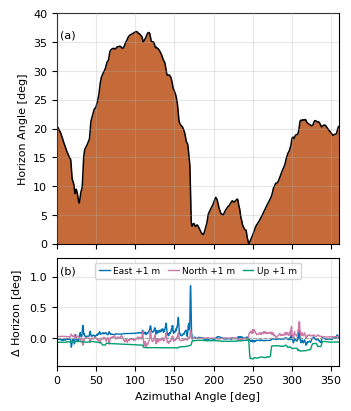

In [6]:
fig_geom = build_horizon_figure(az, alpha, h_names, PREVIEW / "horizon_perturbations_1col.pdf")
print(f"wrote preview {PREVIEW / 'horizon_perturbations_1col.pdf'}")

## 3. The antenna-temperature difference $\Delta T_\mathrm{ant}(\nu)$

`analysis.delta_waterfall` in `uncorrected` mode is the raw difference
`t_sys[i] - t_sys[0]` -- no ground-loss correction. That is the honest choice
here: the position error is by hypothesis *unknown*, so the observer cannot
apply the displaced position's own `fgnd`. (`analysis.MODES` also offers
`oracle` and `miscorrected` for the correction study; the paper figure uses the
uncorrected difference, and the eigenbasis in §4 is built from the same
uncorrected quantity so the comparison is self-consistent.)

The waterfall is sampled at 24 LSTs, one per hour. The residual row of the
figure keeps all three positive magnitudes, not just +1 m: after filtering, the
24 LSTs collapse into one bundle, so an LST colour scale there would
discriminate nothing, whereas the three magnitudes separate by decades and let
a reader scale the result to whatever position knowledge they actually have.

In [7]:
dT_all = analysis.delta_waterfall(t_sys, fgnd, "uncorrected", t_gnd, t_rcvr)

lst_full = (
    Time(d["times_jd"], format="jd", scale="utc")
    .sidereal_time("apparent", longitude=float(d["lon"]) * u.deg)
    .hour
)
# nearest sample to each whole hour of LST, wrapping at 24 h
idx = [int(np.argmin(np.abs((lst_full - hr + 12) % 24 - 12))) for hr in range(24)]
lst = lst_full[idx]


def pos_tag(axis, mag):
    """run_sims.py's name for a positive displacement, e.g. z_p_0p1."""
    return f"{axis}_p_" + ("%g" % mag).replace(".", "p")


dT_disp = np.stack([                          # (3 axis, 3 mag, 24 LST, n_f) K
    np.stack([dT_all[names.index(pos_tag(ax, mg))][idx] for mg in MAGS_M])
    for ax, _ in AXES_ENU
])
labels = [lab for _, lab in AXES_ENU]
i_top = int(np.argmin(np.abs(np.array(MAGS_M) - TOP_MAG)))

# Peak |dT| at TOP_MAG over the FULL waterfall, not the 24 plotted LSTs. The
# 24-LST maximum is a sampling artefact: it swings between 7.8 and 9.3 K for
# the vertical shift depending which 24 hours are picked, whereas the full
# curve is converged -- it moves by 0.01 K between 10-minute and 1-minute
# cadence. The prose and the caption quote a property of the displacement, so
# they quote this; the figure draws 24 curves only for legibility.
max_dT_full = np.array([
    np.abs(dT_all[names.index(pos_tag(ax, TOP_MAG))]).max() for ax, _ in AXES_ENU
])

print("dT_disp", dT_disp.shape, "at magnitudes", MAGS_M, "m")
print("LSTs sampled [h]:", np.round(lst, 1))
print()
for c, lab in enumerate(labels):
    x = dT_disp[c, i_top]
    print(f"{lab:5s} +{TOP_MAG:g} m: RMS {np.sqrt((x**2).mean()):6.3f} K, "
          f"max |dT| {np.abs(x).max():6.3f} K at {freqs[np.abs(x).max(0).argmax()]:.0f} MHz")

dT_disp (3, 3, 24, 201) at magnitudes (0.1, 1.0, 10.0) m
LSTs sampled [h]: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23.]

East  +1 m: RMS  0.387 K, max |dT|  5.258 K at 50 MHz
North +1 m: RMS  0.080 K, max |dT|  0.528 K at 50 MHz
Up    +1 m: RMS  1.008 K, max |dT|  8.864 K at 50 MHz


## 4. The foreground spectral eigenbasis

The basis is the right singular vectors $V^\dagger$ of the **nominal**
antenna-temperature waterfall -- the system temperature minus the constant
receiver temperature, so that the ~50 K offset the basis was never optimised to
compress does not pollute it.

The SVD is **uncentered**: the mean spectrum is kept. It is the dominant
foreground and must be removed by any per-spectrum cleaning, so it counts as
mode 1 rather than being subtracted for free.

These are the same modes as the paper's `foreground_svd.npz` / Fig. 1; the
assert below is the guard that they cannot drift apart.

In [8]:
t_ant = t_sys[0] - t_rcvr                    # (n_time, n_f) K, nominal position

fg_ref = np.load(paper.FG_NPZ)
assert np.array_equal(t_sys[0], fg_ref["t_sys"]), "baseline != foreground_svd.npz"
assert np.array_equal(fg_ref["freqs_MHz"], freqs), "frequency grid mismatch"

U, s, Vh = np.linalg.svd(t_ant, full_matrices=False)

print("Vh", Vh.shape, " first singular values:", np.array2string(s[:6], precision=1))
print("\nper-channel RMS each mode contributes to one spectrum [K]:")
for i in range(6):
    print(f"  mode {i+1}: {s[i] / np.sqrt(n_time * n_f):10.4f}")

Vh (201, 201)  first singular values: [3.9e+05 1.3e+04 1.3e+03 6.4e+02 2.1e+02 6.2e+01]

per-channel RMS each mode contributes to one spectrum [K]:
  mode 1:   728.7085
  mode 2:    23.4149
  mode 3:     2.3689
  mode 4:     1.1898
  mode 5:     0.3856
  mode 6:     0.1162


## 5. The operating point $N_\mathrm{ANCHOR}$

Two curves, both read as a residual RMS after filtering the leading $N$ modes:

* the **foreground floor** -- what the nominal foregrounds themselves leave
  behind, pooled over every time and channel. By Parseval this is just the
  singular-value tail, $\sqrt{\sum_{i>N} s_i^2 / (n_t n_f)}$.
* the **retained 21 cm signal** -- the model ensemble under the identical
  projection, as 5/50/95th percentiles.

$N_\mathrm{ANCHOR}$ is the smallest $N$ at which the foreground floor falls
below the *median* retained signal **and stays below it** for every larger $N$.
Only the foreground floor enters the criterion: Fig. 1 is scoped to foreground
dimensionality alone, and the position systematic belongs to the
forward-modelling section (§8 below), where it is measured against the same
benchmark.

The *stays below* clause is the conservative choice, and it is what licenses
the caption's inequality: it asserts something about every larger $N$, not
just about one. With the ensemble in antenna temperature it happens to pick
the same $N$ as a first-crossing rule -- checked on the full 201-mode basis,
the foreground floor crosses the median exactly once and never comes back --
so nothing here turns on it. It did before the ensemble was attenuated: the
worst-LST vertical systematic then sat below the median at $N = 7$ and $8$ and
climbed above it again at $N = 9$, and a first-crossing rule reported that
transient. Keep the clause; it costs nothing and it is the claim the caption
makes.

In [9]:
def resid_curves(dT_axis, Vh, n_modes):
    """Per-row residual RMS over frequency [K] after filtering the leading N modes.

    ``dT_axis`` is (n_row, n_freq); rows are LSTs here and models for the 21 cm
    ensemble. Worst-case (per-row), not pooled -- the position systematic is
    quoted against its worst LST.
    """
    n_f = dT_axis.shape[1]
    coeff = dT_axis @ Vh.T
    return np.array([np.sqrt(np.sum(coeff[:, N:] ** 2, axis=1) / n_f)
                     for N in n_modes])                  # (n_modes, n_row)


def stays_below(curve, ref, n_modes):
    """Smallest N with curve < ref there and at every larger N on the axis.

    Not first-crossing: both fall with N and cross more than once, so a
    first-crossing rule reports an N the curve later climbs back above.
    """
    below = curve < ref
    return next((N for N in n_modes if below[N:].all()), None)

In [10]:
# foreground floor: pooled over rows and channels, i.e. the singular-value tail
fg_resid = np.array([np.sqrt(np.sum(s[N:] ** 2) / (n_time * n_f)) for N in n_modes])

# retained 21 cm signal under the same projection
t21_ret = resid_curves(T21, Vh, n_modes)                 # (n_modes, n_model) K
t21_pct = np.percentile(t21_ret, (5, 50, 95), axis=1)   # (3, n_modes) K

N_ANCHOR = stays_below(fg_resid, t21_pct[1], n_modes)
assert N_ANCHOR is not None, "foreground floor never stays below the median signal"

print(f"{'N':>3}{'fg resid':>11}{'21cm p50':>11}{'21cm p5':>10}{'21cm p95':>10}")
for N in n_modes:
    flag = "  <- N_ANCHOR" if N == N_ANCHOR else ""
    print(f"{N:>3}{fg_resid[N]*1e3:>10.3f}{t21_pct[1, N]*1e3:>11.3f}"
          f"{t21_pct[0, N]*1e3:>10.3f}{t21_pct[2, N]*1e3:>10.3f}  mK{flag}")

print(f"\nN_ANCHOR = {N_ANCHOR}")
assert N_ANCHOR == paper.N_ANCHOR, (
    f"derived N_ANCHOR = {N_ANCHOR}, paper.py says {paper.N_ANCHOR}"
)
print("matches paper.N_ANCHOR, which signal_loss.ipynb also asserts against")

# The handover: where the +TOP_MAG m vertical error overtakes the foreground
# floor. Section 8's anatomy of what the displacement leaves behind is taken
# at this depth rather than at N_ANCHOR, because past it the residual IS the
# position error, and because almost all of what the vertical leaves here is
# the single mode N_ANCHOR filters -- read at N_ANCHOR that anatomy describes
# the remainder after that mode rather than the error itself.
#
# The induced floors of section 6 are NOT read here. They were, until
# 2026-09-03; they now read at N_ANCHOR so that the manuscript quotes them at
# the same depth section 2.1 sets the filter at. N_HAND stays exactly what it
# was -- a first crossing between two curves neither of which moved -- and is
# still published, still asserted here and in signal_loss.ipynb.
_i_top = int(np.argmin(np.abs(np.array(MAGS_M) - TOP_MAG)))
_up = dT_disp[labels.index("Up"), _i_top] @ Vh.T
_sys = np.array([np.sqrt(np.mean(np.sum(_up[:, N:] ** 2, axis=1) / n_f))
                 for N in n_modes])
N_HAND = next(int(N) for N in n_modes if _sys[N] >= fg_resid[N])
assert N_HAND == N_ANCHOR - 1, (
    f"the limit changes hands at N={N_HAND}, not one mode inside "
    f"N_ANCHOR={N_ANCHOR}; paper.py and block 4 both say they are adjacent"
)
print(f"N_HAND = {N_HAND}: the +{TOP_MAG:g} m vertical error overtakes the "
      f"foreground floor one mode inside N_ANCHOR")

  N   fg resid   21cm p50   21cm p5  21cm p95
  0729089.493     13.395     4.570    38.897  mK
  1 23567.940      9.438     3.882    29.135  mK
  2  2681.572      7.257     3.703    25.716  mK
  3  1256.629      7.064     3.520    23.839  mK
  4   404.240      4.881     1.891    15.280  mK
  5   121.259      3.197     1.320     9.339  mK
  6    34.802      2.682     1.130     8.175  mK
  7    18.462      2.495     0.993     7.069  mK
  8     7.786      1.907     0.690     6.366  mK
  9     1.753      1.163     0.454     4.151  mK
 10     0.623      0.870     0.321     3.039  mK  <- N_ANCHOR
 11     0.316      0.759     0.294     2.719  mK
 12     0.178      0.686     0.249     2.532  mK
 13     0.088      0.607     0.209     2.359  mK
 14     0.050      0.452     0.165     1.848  mK
 15     0.015      0.402     0.134     1.740  mK
 16     0.008      0.335     0.110     1.428  mK
 17     0.005      0.291     0.091     1.353  mK
 18     0.002      0.257     0.083     0.998  mK

N_ANCHOR 

## 6. Is the floor a property of the foregrounds, or of the basis?

The modes are the right singular vectors of the **nominal** antenna temperature,
so the foreground floor of §5 is an *in-sample* optimum: by Eckart--Young no
$N$-dimensional basis describes that matrix better. A position error is not in
that matrix, and neither is the 21 cm signal, so the floor and the two things it
gets compared against are not on the same footing. Two checks separate the parts
of that asymmetry.

* **Sampling.** Build the basis from half the sidereal day, evaluate on the
  other half. The waterfall is nowhere near rank-limited -- $N_\mathrm{ANCHOR}$
  is a fraction of a per cent of its rank -- so this should cost nothing.
* **The horizon.** Decompose each *displaced* sky in its own basis. If a
  displaced antenna temperature were intrinsically harder to compress, its own
  floor would rise. If it is not, then the whole of the excess in §8 is the
  price of a basis built for the wrong horizon, and calling it "one more mode"
  would misdescribe it.

Both floors are read at $N_\mathrm{ANCHOR}$, the depth the filter is set at
elsewhere in the paper -- not at the handover $N_\mathrm{HAND}$ one mode
inside it, which is where the vertical perturbation looks worst against the
retained signal and is therefore the wrong place to quote a tolerance from.
The handover still governs §8's anatomy of the leftover, which is a different
question: not how large the floor is, but what the surviving residual is
*made of*.

The second check is the one that bites, and it is why the paper quotes the
*floor a position error induces* rather than a mode count: the mode count is a
threshold crossing between two curves that are equal to within a per cent at
$N_\mathrm{ANCHOR}$, and which of them is larger there depends on whether the
systematic is taken as a worst case over LST or as an average.

A third question falls out of the same arrays, and it is the one an audience
asks: why not simply remove every mode on the plot, since the foreground floor
is then five orders of magnitude down and some signal still survives? Because
that floor is the singular-value tail of the matrix that defined the basis --
Eckart--Young guarantees it plunges, and it is a promise the simulation makes
to itself. Track a real perturbation against it instead and the limiting term
changes hands: the foregrounds are the larger of the two up to $N = 8$, the
1 m vertical error overtakes them at $N = 9$, and beyond $N \sim 12$ it is
consistently larger, by a factor that keeps growing. Past the handover,
filtering deeper removes signal from a residual that is no longer made of
foreground.

The handover sits one mode *inside* $N_\mathrm{ANCHOR}$, and the two are
different questions: the handover is a foreground-vs-systematic crossing,
$N_\mathrm{ANCHOR}$ a foreground-vs-signal one. They coincided while the 21 cm
ensemble was filtered un-attenuated; putting it in antenna temperature
(section 1.2) moved $N_\mathrm{ANCHOR}$ up by one and left the handover
untouched, since neither curve involved in it depends on the 21 cm at all.
`print_handover` prints the crossing and asserts that adjacency, which is what
makes both dimensions landmarks rather than arbitrary choices.


In [11]:
def print_handover(fg_resid, dT_disp, Vh, mags, top_mag, labels, n_modes, n_f):
    """Where does the term limiting the residual change hands?

    The foreground floor is an in-sample optimum, so it falls faster with N
    than anything not used to build the basis. Past the point where an
    unmodelled position error overtakes it, filtering deeper removes signal
    from a residual that is no longer made of foreground -- which is the answer
    to "why not just remove every mode on the plot".
    """
    k = int(np.argmin(np.abs(mags - top_mag)))
    up = dT_disp[labels.index("Up"), k] @ Vh.T
    sys_r = np.array([np.sqrt(np.mean(np.sum(up[:, N:] ** 2, axis=1) / n_f))
                      for N in n_modes])
    first = next(N for N in n_modes if sys_r[N] >= fg_resid[N])
    stays = next(N for N in n_modes if (sys_r[N:] > fg_resid[N:]).all())
    print(f"{'N':>3}{'fg floor':>12}{'+%g m up' % top_mag:>12}{'limited by':>13}")
    for N in n_modes:
        who = "foregrounds" if fg_resid[N] > sys_r[N] else "position"
        print(f"{N:>3}{fg_resid[N] * 1e3:11.4f}{sys_r[N] * 1e3:11.4f}  {who:>12}")
    print(f"\nforegrounds larger by {fg_resid[first - 1] / sys_r[first - 1]:.1f}x "
          f"at N={first - 1}; the two cross at N={first}; from N={stays} the "
          f"position error is consistently larger, reaching "
          f"{sys_r[-1] / fg_resid[-1]:.1f}x at N={n_modes[-1]}")
    return first, stays


def print_floor_table(pos_names, floor_own, floor_nom, cv_pen, n_anchor,
                      n_time, n_f):
    """How much of the floor is the foregrounds, and how much is the basis?"""
    base = floor_own[0]
    print(f"nominal floor at N={n_anchor}: {base * 1e3:.3f} mK")
    print(f"held-out LST penalty: {cv_pen:.2f}x   ({n_time} spectra x {n_f} "
          f"channels; {n_anchor} of a possible {min(n_time, n_f)} modes)")
    print(f"\n{'displacement':14s}{'own basis':>13s}{'nominal basis':>16s}"
          f"{'floor':>9s}")
    for nm, o, nb in zip(pos_names, floor_own, floor_nom):
        if nm == pos_names[0]:
            continue
        print(f"{nm:14s}{o * 1e3:10.3f} mK{nb * 1e3:13.3f} mK{nb / base:8.2f}x")


def print_compressibility(s_fg, dT_disp, Vh, labels, mags, top_mag,
                          n_time, n_f, n_anchor):
    """Is a position error 'more foreground'? Only in the crudest sense."""
    i_top = int(np.argmin(np.abs(mags - top_mag)))
    fg = s_fg ** 2
    hdr = (f"{'':12s}{'leak past 2':>13s}{'decades 1-10':>14s}{'RMS':>11s}"
           f"{'floor':>11s}{'compression':>13s}")
    print(hdr)
    rms = np.sqrt(fg.sum() / (n_time * n_f))
    flr = np.sqrt(fg[n_anchor:].sum() / (n_time * n_f))
    print(f"{'foregrounds':12s}{1 - fg[:2].sum() / fg.sum():13.2e}"
          f"{np.log10(fg[0] / fg[9]):14.1f}{rms:9.1f} K{flr * 1e3:8.2f} mK"
          f"{rms / flr:13.0f}")
    for c, lab in enumerate(labels):
        co = dT_disp[c, i_top] @ Vh.T
        p = (co ** 2).sum(axis=0)
        n_row = co.shape[0]
        rms = np.sqrt(p.sum() / (n_row * n_f))
        flr = np.sqrt(p[n_anchor:].sum() / (n_row * n_f))
        print(f"{lab + ' ' + '%g' % top_mag + ' m':12s}"
              f"{1 - p[:2].sum() / p.sum():13.2e}"
              f"{np.log10(p[0] / p[9]):14.1f}{rms:9.3f} K{flr * 1e3:8.2f} mK"
              f"{rms / flr:13.0f}")


def floor_from_sv(sv, n_rows, n_anchor, n_f):
    """In-sample floor [K] from a singular-value tail (Parseval)."""
    return np.sqrt(np.sum(sv[n_anchor:] ** 2) / (n_rows * n_f))


def floor_in_basis(mat, Vh, n_anchor):
    """Floor [K] of ``mat`` evaluated in a basis it did not help build."""
    c = mat @ Vh.T
    return np.sqrt(np.sum(c[:, n_anchor:] ** 2) / mat.size)


# Sampling: does half the sidereal day describe the other half?
cv_pen = 0.0
for tr, te in ((t_ant[0::2], t_ant[1::2]), (t_ant[1::2], t_ant[0::2])):
    s_tr, Vh_tr = np.linalg.svd(tr, full_matrices=False)[1:]
    cv_pen = max(cv_pen, floor_in_basis(te, Vh_tr, N_ANCHOR)
                 / floor_from_sv(s_tr, tr.shape[0], N_ANCHOR, n_f))

# The horizon: every simulated sky, in its own basis and in the nominal one.
# Read at N_ANCHOR, not at N_HAND. The handover is where the vertical error
# becomes the term that limits the residual, and it is the right depth for the
# anatomy of the leftover (section 8) -- but it is also, exactly, the depth at
# which the perturbation looks worst against the retained signal, one mode
# short of the depth the paper says the filter needs. Quoting an induced floor
# there and the filter depth at N_ANCHOR is not a defensible pair, so both the
# manuscript's section 2.1 and its section 5.5 now read at N_ANCHOR.
floor_own = np.array([
    floor_from_sv(np.linalg.svd(t_sys[p] - t_rcvr, full_matrices=False,
                                compute_uv=False), n_time, N_ANCHOR, n_f)
    for p in range(len(names))
])
floor_nom = np.array([floor_in_basis(t_sys[p] - t_rcvr, Vh, N_ANCHOR)
                      for p in range(len(names))])
assert np.isclose(floor_own[0], floor_nom[0]), "nominal must be its own optimum"
assert floor_own.max() < 3 * floor_own[0], (
    "a displaced sky is now materially harder to compress in its own basis; "
    "block 5's 'not a more complex object' no longer holds"
)

print_floor_table(names, floor_own, floor_nom, cv_pen, N_ANCHOR, n_time, n_f)
print()
print_compressibility(s, dT_disp, Vh, labels, np.array(MAGS_M), TOP_MAG,
                      n_time, n_f, N_ANCHOR)
print()
n_hand, n_hand_stay = print_handover(fg_resid, dT_disp, Vh, np.array(MAGS_M),
                                     TOP_MAG, labels, n_modes, n_f)
assert n_hand == N_HAND, (
    f"print_handover says the limit changes hands at N={n_hand}, but section 5 "
    f"derived N_HAND={N_HAND} from the same arrays"
)

nominal floor at N=10: 0.623 mK
held-out LST penalty: 1.00x   (1436 spectra x 201 channels; 10 of a possible 201 modes)

displacement      own basis   nominal basis    floor
x_m_0p1            0.623 mK        0.623 mK    1.00x
x_p_0p1            0.623 mK        0.623 mK    1.00x
x_m_1              0.622 mK        0.631 mK    1.01x
x_p_1              0.624 mK        0.635 mK    1.02x
x_m_10             0.611 mK        1.254 mK    2.01x
x_p_10             0.635 mK        1.463 mK    2.35x
y_m_0p1            0.623 mK        0.623 mK    1.00x
y_p_0p1            0.623 mK        0.623 mK    1.00x
y_m_1              0.626 mK        0.626 mK    1.01x
y_p_1              0.620 mK        0.620 mK    1.00x
y_m_10             0.653 mK        0.694 mK    1.11x
y_p_10             0.593 mK        0.654 mK    1.05x
z_m_0p1            0.622 mK        0.623 mK    1.00x
z_p_0p1            0.624 mK        0.625 mK    1.00x
z_m_1              0.612 mK        0.695 mK    1.12x
z_p_1              0.634 mK    

## 7. The figure

**Fig. `horizon_shift.pdf`** in the paper: 2 rows $\times$ 3 axes.

*Top* -- the $\Delta T_\mathrm{ant}(\nu)$ spectra at +1 m, coloured by LST.
*Bottom* -- their residual RMS after filtering the leading $N$ foreground
modes, one bundle per displacement magnitude, against the retained 21 cm signal
(5-95% band, median dashed) under the identical projection.

The two rows encode different variables on purpose: LST above (cyclic colormap,
the honest choice for a quantity that wraps) and displacement below (sequential
single-hue, because displacement is ordered and light-to-dark reads without a
legend lookup). The 21 cm band is grey and dashed so it reads as a benchmark in
both rows without competing with either row's colour encoding.

Fig. 1's operating point is deliberately *not* drawn here. A dotted line tagged
"N = 9" was tried and dropped: the number is meaningless without the other
figure, and unlabelled it was just an unexplained rule. It governs §7 and the
paper text instead, which is where the comparison belongs.

In [12]:
def make_figure(freqs, lst, t21, dT_disp, mags, top_mag, Vh, labels, n_modes, out_path):
    """The 2x3 horizon-shift figure. Returns the figure; also writes ``out_path``."""
    CMAP, norm = "twilight", Normalize(0, 24)
    C_21 = "0.40"                     # 21 cm band: grey and dashed, so it reads as
                                      # a benchmark in both rows without competing
                                      # with either row's colour encoding.
    D_COL = ["#6baed6", "#2171b5", "#08306b"]   # sequential: displacement is ordered
    cmap = plt.get_cmap(CMAP)
    n_f = freqs.size
    i_top = int(np.argmin(np.abs(mags - top_mag)))
    dT = dT_disp[:, i_top]                                  # (3, n_lst, n_freq)

    fig, axes = plt.subplots(
        2, 3, figsize=(7.3, 3.6),
        gridspec_kw=dict(height_ratios=[1.6, 1.15]),
        layout="constrained",
    )
    for col, lab in enumerate(labels):
        at, ab = axes[0, col], axes[1, col]
        for j in range(lst.size):                           # top: dT(nu) spectra
            at.plot(freqs, dT[col, j], color=cmap(norm(lst[j])), lw=0.7, alpha=0.9)
        at.axhline(0, color="0.5", lw=0.6, ls="--", zorder=0)
        at.set_title(lab, fontsize=8.5)
        at.set_xlabel("Frequency [MHz]", fontsize=8)
        at.grid(alpha=0.2); at.tick_params(labelsize=7)
        # Headroom for the magnitude tag. The three panels span very different
        # ranges and the curves reach the top of a different one in each, so the
        # tag needs space made for it rather than a corner that happens to be free.
        lo, hi = dT[col].min(), dT[col].max()
        at.set_ylim(lo - 0.05 * (hi - lo), hi + 0.30 * (hi - lo))
        at.text(0.97, 0.94, f"$+{top_mag:g}$ m", transform=at.transAxes,
                fontsize=6.5, color="0.35", ha="right", va="top")

        for k in range(mags.size):                          # bottom: all magnitudes
            rc = resid_curves(dT_disp[col, k], Vh, n_modes)  # (n_modes, n_lst)
            for j in range(lst.size):
                ab.plot(n_modes, rc[:, j], color=D_COL[k], lw=0.55, alpha=0.6)
        ab.fill_between(n_modes, t21[0], t21[2], color=C_21, alpha=0.25, lw=0, zorder=0)
        ab.plot(n_modes, t21[1], color=C_21, lw=1.4, ls="--", zorder=1)
        ab.set_yscale("log")
        ab.set_xlabel("Foreground modes filtered", fontsize=8)
        ab.grid(True, which="both", ls=":", lw=0.5, alpha=0.55)
        ab.set_xlim(0, n_modes[-1]); ab.set_ylim(3e-5, 30); ab.tick_params(labelsize=7)

    axes[0, 0].set_ylabel(r"$\Delta T_\mathrm{ant}$ [K]", fontsize=8)
    axes[1, 0].set_ylabel("Residual RMS [K]", fontsize=8)
    handles = [Line2D([], [], color=D_COL[k], lw=2, label=f"{mg:g} m")
               for k, mg in enumerate(mags)]
    handles.append(Line2D([], [], color=C_21, lw=1.4, ls="--", label="21-cm models"))
    # Upper right, not lower left: every curve descends with N, so the top-right
    # corner is the one reliably empty region in all three residual panels, while
    # the lower left still carries the 0.1 m tails.
    axes[1, 0].legend(handles=handles, fontsize=5.8, loc="upper right", ncol=2,
                      framealpha=0.9, handlelength=1.4, columnspacing=0.9,
                      borderpad=0.3, labelspacing=0.25)
    for col in (1, 2):
        axes[1, col].tick_params(labelleft=False)

    sm = ScalarMappable(norm=norm, cmap=CMAP)
    cb = fig.colorbar(sm, ax=axes[0, :], pad=0.012, fraction=0.03)
    cb.set_label("LST [h]", fontsize=8); cb.set_ticks(np.arange(0, 25, 6))
    cb.ax.tick_params(labelsize=7)

    fig.savefig(out_path, bbox_inches="tight", dpi=600)
    return fig

wrote preview /home/christian/Documents/research/eigsep/mock_analysis/horizon_position/output/preview/horizon_shift.pdf


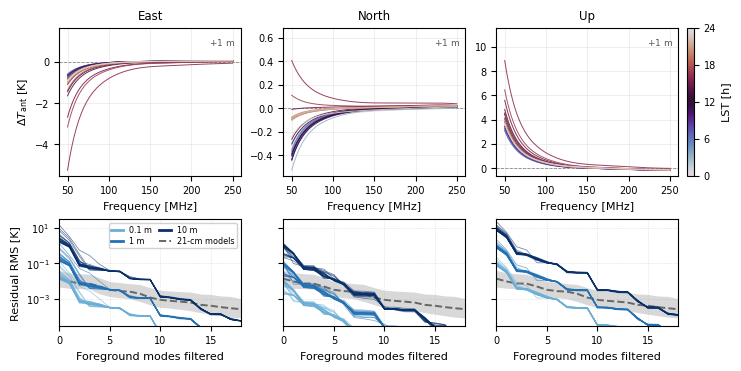

In [13]:
mags = np.array(MAGS_M)
fig_shift = make_figure(freqs, lst, t21_pct, dT_disp, mags, TOP_MAG, Vh,
                        labels, n_modes, PREVIEW / "horizon_shift.pdf")
print(f"wrote preview {PREVIEW / 'horizon_shift.pdf'}")

## 8. The numbers quoted in the paper

The bottom row makes two points at once, and they pull opposite ways.

*Reassuring.* A position error is not a new kind of spectral structure. The
$\Delta T$ are large -- up to ~9 K at 50 MHz, ~1 K RMS for the upward shift --
but almost all of that power lies in the two leading eigenmodes of the
unperturbed antenna temperature. It is, to that accuracy, more foreground, and
the same low-order filtering that removes the sky removes almost all of it.

*Cautionary.* What survives is narrow, not smooth. After $N_\mathrm{HAND}$
modes -- the depth at which the position error overtakes the foregrounds --
99 per cent of the Up displacement's remaining power sits in a single mode, at
3.2 mK against a 1.2 mK median retained signal, and similar enough in shape to
be confused with it. That single mode is also exactly the one the vertical
needs filtered before it drops under the median. A fixed-depth filter set
either side of it gets a completely different answer, which is the argument
for modelling the displacement rather than filtering to a depth.

The vertical response is the one that is linear in displacement, because a
vertical shift lowers the horizon by a near-uniform offset; East and North are
not, since a horizontal shift moves the horizon by an amount set by where the
cliff edges fall in azimuth. Up is also the binding axis at every $N$, so the
extrapolation is sound and the resulting requirement is a vertical one.

In [14]:
def print_summary(dT_disp, mags, top_mag, Vh, labels, lst, t21, n_modes,
                  n_anchor, n_hand):
    """Every number the paper text quotes from this figure.

    ``n_anchor`` is where the foreground floor clears the median retained
    signal; ``n_hand`` is one mode inside it, where the position error
    overtakes the foreground floor. The anatomy of what escapes is taken at
    ``n_hand`` -- past it the residual is the position error, which is what
    makes "what survives the filter" the right question there. At ``n_anchor``
    the spike below has already been filtered out.
    """
    n_f = dT_disp.shape[-1]
    i_top = int(np.argmin(np.abs(mags - top_mag)))
    worst = np.array([[resid_curves(dT_disp[c, k], Vh, n_modes).max(axis=1)
                       for k in range(mags.size)]
                      for c in range(len(labels))])        # (axis, mag, n_modes)

    med21 = t21[1, n_anchor] * 1e3
    print(f"worst-LST residual, median retained 21 cm at N={n_anchor} is {med21:.2f} mK\n")
    print(f"{'axis':7s}{'shift':>8s}{'unfiltered':>12s}{'at N=%d' % n_anchor:>10s}"
          f"{'stays below from':>18s}")
    for c, lab in enumerate(labels):
        for k, mg in enumerate(mags):
            w = worst[c, k]
            print(f"{lab if k == 0 else '':7s}{mg:7g}m{w[0]*1e3:11.1f} mK"
                  f"{w[n_anchor]*1e3:9.2f} mK"
                  f"{stays_below(w, t21[1], n_modes):15d} modes")

    worst_all = worst[:, i_top].max(axis=0)
    n_sys = stays_below(worst_all, t21[1], n_modes)
    print(f"\nFig. 1 sets N = {n_anchor} on the foreground residual alone. Folding in "
          f"the +{top_mag:g} m position systematic costs {n_sys - n_anchor} further "
          f"mode(s): worst axis/LST {worst_all[n_anchor]*1e3:.2f} mK at N = {n_anchor} "
          f"(median retained {med21:.2f} mK), {worst_all[n_sys]*1e3:.2f} mK at "
          f"N = {n_sys} (median retained {t21[1, n_sys]*1e3:.2f} mK).")

    # Does the residual scale with displacement? Only on the vertical axis.
    print()
    for c, lab in enumerate(labels):
        r = worst[c, :, n_anchor]
        dev = np.abs((r[1:] / r[:-1]) / (mags[1:] / mags[:-1]) - 1) * 100
        print(f"{lab:7s} deviation from proportionality per decade: "
              + ", ".join(f"{x:.1f}%" for x in dev))

    i_up = labels.index("Up")
    med_hand = t21[1, n_hand] * 1e3
    spec = 0.1 * med_hand / (worst[i_up, i_top, n_hand] * 1e3) * top_mag
    print(f"\nUp is linear, and is the binding axis at every N. Holding its injection "
          f"to a tenth of the median retained signal at N = {n_hand} needs the "
          f"vertical position known to {spec:.2f} m.")

    # The two halves of the message, as numbers, taken at the handover.
    cu = dT_disp[2, i_top] @ Vh.T                          # Up, every LST
    j = int(np.argmax(np.sqrt(np.sum(cu[:, n_hand:]**2, axis=1))))
    mode_mK = np.abs(cu[j]) / np.sqrt(n_f) * 1e3
    lead = np.sum(cu[j, :2]**2) / np.sum(cu[j]**2)
    spike = int(np.argmax(mode_mK[n_hand:])) + n_hand
    tail = np.sum(mode_mK[n_hand:]**2)
    print(f"\nUp +{top_mag:g} m at LST {lst[j]:.0f} h: {lead*100:.1f}% of its power "
          f"sits in the two leading foreground modes -- mostly just more foreground. But "
          f"after filtering {n_hand} modes, {mode_mK[spike]**2/tail*100:.0f}% of what "
          f"remains is mode {spike+1} alone, at {mode_mK[spike]:.2f} mK against a "
          f"{med_hand:.2f} mK median retained signal, {mode_mK[spike]/med_hand:.1f}x "
          f"its magnitude. Filtering that one mode is what "
          f"drops the vertical under the median, so a fixed-depth filter set either "
          f"side of it reports a different result.")

In [15]:
print_summary(dT_disp, mags, TOP_MAG, Vh, labels, lst, t21_pct, n_modes,
              N_ANCHOR, n_hand)

worst-LST residual, median retained 21 cm at N=10 is 0.87 mK

axis      shift  unfiltered   at N=10  stays below from
East       0.1m      128.9 mK     0.01 mK              2 modes
             1m     1303.0 mK     0.12 mK              7 modes
            10m    14263.6 mK     1.51 mK             14 modes
North      0.1m       12.7 mK     0.00 mK              0 modes
             1m      131.1 mK     0.04 mK              2 modes
            10m     1341.5 mK     0.37 mK             10 modes
Up         0.1m      214.5 mK     0.04 mK              3 modes
             1m     2147.7 mK     0.35 mK             10 modes
            10m    21924.5 mK     3.37 mK             17 modes

Fig. 1 sets N = 10 on the foreground residual alone. Folding in the +1 m position systematic costs 0 further mode(s): worst axis/LST 0.35 mK at N = 10 (median retained 0.87 mK), 0.35 mK at N = 10 (median retained 0.87 mK).

East    deviation from proportionality per decade: 3.1%, 21.2%
North   deviation from prop

## 9. Export to the paper repository

The paper repo's convention is a committed npz (archived to Zenodo) plus a
*standalone* notebook that regenerates the PDF from it -- it cannot import
anything from this repo, and it has no access to `position_sims.npz` or the
Zeus21 ensemble.

The plotting code is therefore not duplicated: `inspect.getsource` lifts the
functions defined above straight out of the running kernel, so the exported
notebook contains byte-identical code to what produced the figures in this one.
Changing a plot above and re-running is the only way to change what ships.

In [16]:
# ---- provenance, written by the notebook rather than added afterwards ------
# Both deposits used to carry `params`/`provenance` that nothing here wrote:
# they were added to the npz by hand, so every re-run of this notebook silently
# stripped them. Building them here is what makes them survive.
import subprocess


def _sha(repo, short=7):
    """Short git SHA of ``repo``'s HEAD, flagged if the tree is dirty."""
    try:
        head = subprocess.run(
            ["git", "-C", str(repo), "rev-parse", f"--short={short}", "HEAD"],
            capture_output=True, text=True, check=True,
        ).stdout.strip()
    except (subprocess.CalledProcessError, OSError):
        return "not-a-git-repo"
    dirty = subprocess.run(
        ["git", "-C", str(repo), "status", "--porcelain"],
        capture_output=True, text=True,
    ).stdout.strip()
    return head + ("-dirty" if dirty else "")


MOCK_SHA = _sha(paper.ROOT)
POS_SHA = str(d["pos_sha"])

_HORIZON_LINEAGE = (
    "Horizons come from the float32-DEM / OVERSAMPLE=64 rerun: eigsep_terrain "
    "dem.py reads the lidar GeoTIFFs as float32 rather than truncating every "
    "elevation to a whole metre, and make_horizons.py computes alpha_h on a "
    "64x finer azimuth grid. "
)
_SMOOTHING = (
    "Figures do NOT plot alpha_h as stored. Below about 0.5 deg the difference "
    "curves stop behaving like a geometric response -- East corr(+d,-d) = -0.30 "
    "against the -1 a real response must give, and RMS growing 6.0x rather than "
    "10x between 0.1 and 1 m -- because calc_horizon takes a winner-take-all max "
    "over discrete DEM pixels, so a horizontal move re-sorts which pixel wins and "
    "the jump size is set by those pixels' elevations. Both panels are smoothed "
    "with a 1.40 deg running mean = 360/258, the MWSS cell at lmax = 128 and the "
    "resolution at which open_sky_weight samples the horizon; that restores both "
    "tells (-0.998, 10.06). Smoothed peaks: East +0.850, North +0.262, Up -0.339 "
    "deg. The simulations band-limit separately via masks.reduce_azimuth, which "
    "scores -0.99 on the same test, so dT_ant is unaffected."
)

PROV_PERT = (
    f"mock_analysis@{MOCK_SHA}. pos_sha {POS_SHA} matches "
    "horizon_position/output/position_sims.npz's pos_sha exactly, confirming the "
    "same 19-position configuration underlies both files. " + _HORIZON_LINEAGE
    + "pos_sha hashes the antenna POSITIONS only -- it does not change when the "
    "terrain model does, so it is not a staleness guard for the DEM."
)
PROV_SHIFT = (
    f"mock_analysis@{MOCK_SHA}. Built from "
    f"horizon_position/output/position_sims.npz (pos_sha {POS_SHA}, "
    f"eigsim_version {str(d['eigsim_version'])}). " + _HORIZON_LINEAGE
    + "Vh/s_fg are stored here but derived in-notebook from foreground_svd.npz, "
    "whose t_sys this notebook asserts byte-equal to position_sims.npz row 0."
)
PARAMS_SHIFT = (
    "n_modes = arange(19); n_anchor as stored; "
    "Vh = svd(foreground_svd.npz t_sys - t_receiver).Vh, uncentered."
)
PARAMS_PERT = (
    f"az_grid: {int(h['n_az'])} points, {360 / int(h['n_az']):.4g} deg spacing, "
    "az = atan2(E, N) (North->East), stored in radians. alpha_h: horizon "
    "elevation angle [rad] per az bin, from a Marjum DEM ray-trace at that "
    "resolution. names order: nominal, then +/-0.1/1/10 m single-axis offsets "
    "along East(x)/North(y)/Up(z) from nominal, with enu[nominal] = "
    f"[{', '.join('%g' % v for v in np.asarray(h['enu'])[h_names.index('nominal')])}] m. "
    + _SMOOTHING
)
print(f"provenance built at mock_analysis@{MOCK_SHA}")


# ---- horizon_shift: data + standalone notebook -----------------------------
np.savez_compressed(
    paper.SHIFT_NPZ,
    dT_disp=dT_disp,
    max_dT_full=max_dT_full,
    mags_m=mags,
    top_mag_m=TOP_MAG,
    Vh=Vh,
    freqs_MHz=freqs,
    lst_hr=lst,
    labels=np.array(labels),
    t21_pct=t21_pct,
    n_anchor=N_ANCHOR,
    n_hand=n_hand,
    s_fg=s,
    pos_names=np.array(names),
    floor_own=floor_own,
    floor_nom=floor_nom,
    cv_penalty=cv_pen,
    n_time=n_time,
    description=(
        "Uncorrected antenna-temperature differences dT_ant(nu) for "
        "East/North/Up antenna displacements at 24 LSTs (one per hour), and "
        "the foreground spectral modes Vh (right singular vectors of the "
        "nominal antenna-temperature waterfall = foreground_svd.npz system "
        "temperature minus the constant receiver). dT_disp (3 axis, 3 "
        "magnitude, 24 LST, n_freq) in K; axis order East/North/Up, "
        "max_dT_full (3,) is peak |dT_ant| at top_mag_m over every simulated "
        "LST, not only the 24 stored here -- the 24-LST peak depends on which "
        "hours are sampled, this does not. "
        "magnitudes mags_m in metres, all positive displacements. "
        "top_mag_m is the magnitude the spectra row of the figure draws. "
        "t21_pct (3, n_modes) is the retained 21 cm RMS in ANTENNA "
        "TEMPERATURE: the ensemble is multiplied by the beam-weighted "
        "open-sky fraction eta = 1 - fgnd of the nominal position before "
        "filtering, because dT_disp and Vh are both uncorrected antenna "
        "temperature and an isotropic signal enters that observable "
        "attenuated. n_anchor is the dimension signal_loss.pdf sets on the "
        "foreground residual alone, marked here so both figures read "
        "against one reference, and the dimension the induced floors below "
        "are read at; n_hand is one mode inside it, where the position "
        "systematic overtakes the foreground floor as the term limiting the "
        "residual, and is the dimension the anatomy of the leftover is quoted "
        "at -- a first crossing between two curves, not a filter depth, and "
        "deliberately NOT where the floors are read: it is the depth at which "
        "the perturbation looks worst against the retained signal. s_fg holds "
        "the singular values of that "
        "waterfall. floor_own/floor_nom (n_pos,) are the residual floor at "
        "n_anchor for every simulated position, decomposed in its OWN basis "
        "and in the nominal one: their near-equality in the own-basis column "
        "is what shows a displaced sky is not intrinsically less compressible, "
        "so the excess is basis mismatch and not extra spectral complexity. "
        "pos_names labels them; cv_penalty is the held-out-LST floor ratio, "
        "which separates that mismatch from ordinary in-sample optimism. "
        "Produced by "
        "mock_analysis/horizon_position/notebooks/horizon_shift.ipynb."
    ),
    params=PARAMS_SHIFT,
    provenance=PROV_SHIFT,
)
print(f"wrote {PAPER / 'horizon_shift.npz'}")

provenance built at mock_analysis@47cf114-dirty
wrote /home/christian/Documents/research/papers/eigsep_instrument/notebooks/horizon_shift.npz


In [17]:
# ---- horizon_perturbations: data + standalone notebook ---------------------
np.savez_compressed(
    PAPER / "horizon_perturbations.npz",
    names=np.array(h_names),
    enu=h["enu"],
    az_grid=h["az_grid"],
    alpha_h=h["alpha_h"],
    n_az=h["n_az"],
    pos_sha=h["pos_sha"],
    smooth_deg=SMOOTH_DEG,
    description=(
        "Horizon elevation profiles alpha_h(az) [rad] from the Marjum DEM for "
        "19 antenna positions (nominal, +/-0.1/1/10 m along East/North/Up). "
        "az_grid = atan2(E, N), North->East. Index order matches `names`. "
        "n_az = 46080 (0.0078 deg) is the stored resolution. It is NOT a grid to "
        "plot or analyse on: below about 0.5 deg the difference curves stop "
        "behaving like a geometric response (East corr(+d,-d) = -0.30 against "
        "the -1 required, and RMS growing 6.0x rather than 10x between 0.1 and "
        "1 m), because calc_horizon takes a winner-take-all max over discrete "
        "DEM pixels and a horizontal move re-sorts which pixel wins. Both "
        "figures therefore smooth with a 1.40 deg running mean = 360/258, the "
        "MWSS cell at lmax = 128, which restores both tells (-0.998, 10.1). "
        "The simulations band-limit to 720 bins instead, because their mask "
        "point-samples in azimuth -- one call to mock_analysis "
        "horizon_position/masks.py reduce_azimuth, which is the only place "
        "that reduction happens, and it scores -0.99 on the same test. "
        "smooth_deg is the azimuth width of the running mean both figure "
        "panels are drawn through; apply it to alpha_h to reproduce them "
        "exactly. alpha_h itself is stored unsmoothed, because the "
        "simulations band-limit it differently (720 bins, reduce_azimuth) "
        "and dT_ant must stay reproducible from the same array. "
        "Produced by "
        "mock_analysis/horizon_position/notebooks/horizon_shift.ipynb."
    ),
    params=PARAMS_PERT,
    provenance=PROV_PERT,
)
print(f"wrote {PAPER / 'horizon_perturbations.npz'}")

wrote /home/christian/Documents/research/papers/eigsep_instrument/notebooks/horizon_perturbations.npz
